## 1. Wczytanie danych

In [1]:
import pandas as pd

# nazwy kolumn
columns = [
    "class",
    "cap-shape",
    "cap-surface",
    "cap-color",
    "bruises",
    "odor",
    "gill-attachment",
    "gill-spacing",
    "gill-size",
    "gill-color",
    "stalk-shape",
    "stalk-root",
    "stalk-surface-above-ring",
    "stalk-surface-below-ring",
    "stalk-color-above-ring",
    "stalk-color-below-ring",
    "veil-type",
    "veil-color",
    "ring-number",
    "ring-type",
    "spore-print-color",
    "population",
    "habitat"
]


df = pd.read_csv(
    "grzybole.data",
    header=None,
    names=columns
)


maps = {

    "class": {
        "e": "edible",
        "p": "poisonous"
    },

    "cap-shape": {
        "b": "bell",
        "c": "conical",
        "x": "convex",
        "f": "flat",
        "k": "knobbed",
        "s": "sunken"
    },

    "cap-surface": {
        "f": "fibrous",
        "g": "grooves",
        "y": "scaly",
        "s": "smooth"
    },

    "cap-color": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "r": "green",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },

    "bruises": {
        "t": "bruises",
        "f": "no"
    },

    "odor": {
        "a": "almond",
        "l": "anise",
        "c": "creosote",
        "y": "fishy",
        "f": "foul",
        "m": "musty",
        "n": "none",
        "p": "pungent",
        "s": "spicy"
    },

    "gill-attachment": {
        "a": "attached",
        "d": "descending",
        "f": "free",
        "n": "notched"
    },

    "gill-spacing": {
        "c": "close",
        "w": "crowded",
        "d": "distant"
    },

    "gill-size": {
        "b": "broad",
        "n": "narrow"
    },

    "gill-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "g": "gray",
        "r": "green",
        "o": "orange",
        "p": "pink",
        "u": "purple",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },

    "stalk-shape": {
        "e": "enlarging",
        "t": "tapering"
    },

    "stalk-root": {
        "b": "bulbous",
        "c": "club",
        "u": "cup",
        "e": "equal",
        "z": "rhizomorphs",
        "r": "rooted",
        "?": "unknown"
    },

    "stalk-surface-above-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },

    "stalk-surface-below-ring": {
        "f": "fibrous",
        "y": "scaly",
        "k": "silky",
        "s": "smooth"
    },

    "stalk-color-above-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },

    "stalk-color-below-ring": {
        "n": "brown",
        "b": "buff",
        "c": "cinnamon",
        "g": "gray",
        "o": "orange",
        "p": "pink",
        "e": "red",
        "w": "white",
        "y": "yellow"
    },

    "veil-type": {
        "p": "partial",
        "u": "universal"
    },

    "veil-color": {
        "n": "brown",
        "o": "orange",
        "w": "white",
        "y": "yellow"
    },

    "ring-number": {
        "n": "none",
        "o": "one",
        "t": "two"
    },

    "ring-type": {
        "c": "cobwebby",
        "e": "evanescent",
        "f": "flaring",
        "l": "large",
        "n": "none",
        "p": "pendant",
        "s": "sheathing",
        "z": "zone"
    },

    "spore-print-color": {
        "k": "black",
        "n": "brown",
        "b": "buff",
        "h": "chocolate",
        "r": "green",
        "o": "orange",
        "u": "purple",
        "w": "white",
        "y": "yellow"
    },

    "population": {
        "a": "abundant",
        "c": "clustered",
        "n": "numerous",
        "s": "scattered",
        "v": "several",
        "y": "solitary"
    },

    "habitat": {
        "g": "grasses",
        "l": "leaves",
        "m": "meadows",
        "p": "paths",
        "u": "urban",
        "w": "waste",
        "d": "woods"
    }
}


for col, mapping in maps.items():
    df[col] = df[col].map(mapping)


print(df.head())

       class cap-shape cap-surface cap-color  bruises     odor  \
0  poisonous    convex      smooth     brown  bruises  pungent   
1     edible    convex      smooth    yellow  bruises   almond   
2     edible      bell      smooth     white  bruises    anise   
3  poisonous    convex       scaly     white  bruises  pungent   
4     edible    convex      smooth      gray       no     none   

  gill-attachment gill-spacing gill-size gill-color  ...  \
0            free        close    narrow      black  ...   
1            free        close     broad      black  ...   
2            free        close     broad      brown  ...   
3            free        close    narrow      brown  ...   
4            free      crowded     broad      black  ...   

  stalk-surface-below-ring stalk-color-above-ring stalk-color-below-ring  \
0                   smooth                  white                  white   
1                   smooth                  white                  white   
2             

## 2. EDA

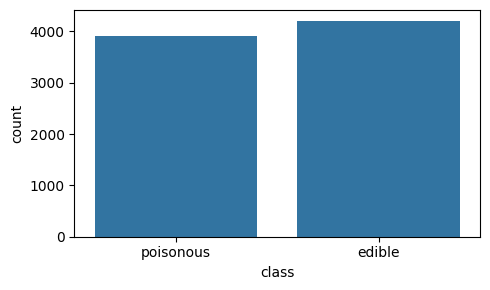

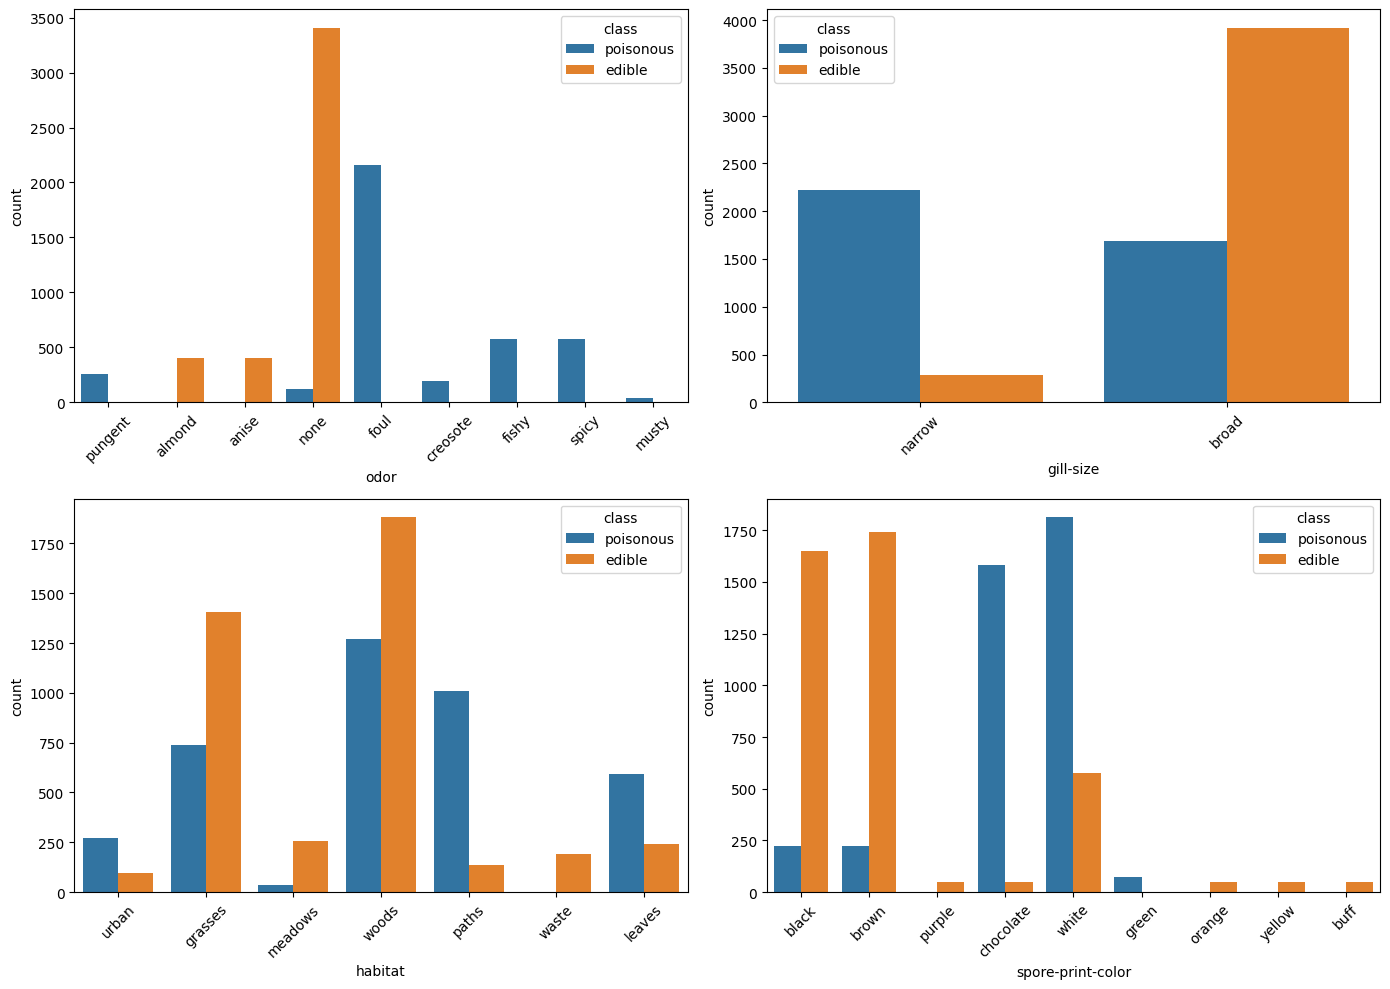

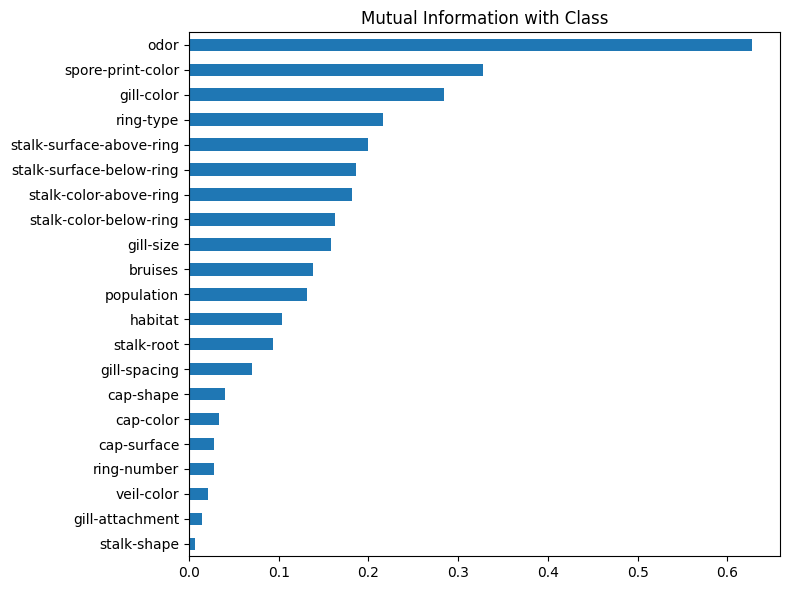

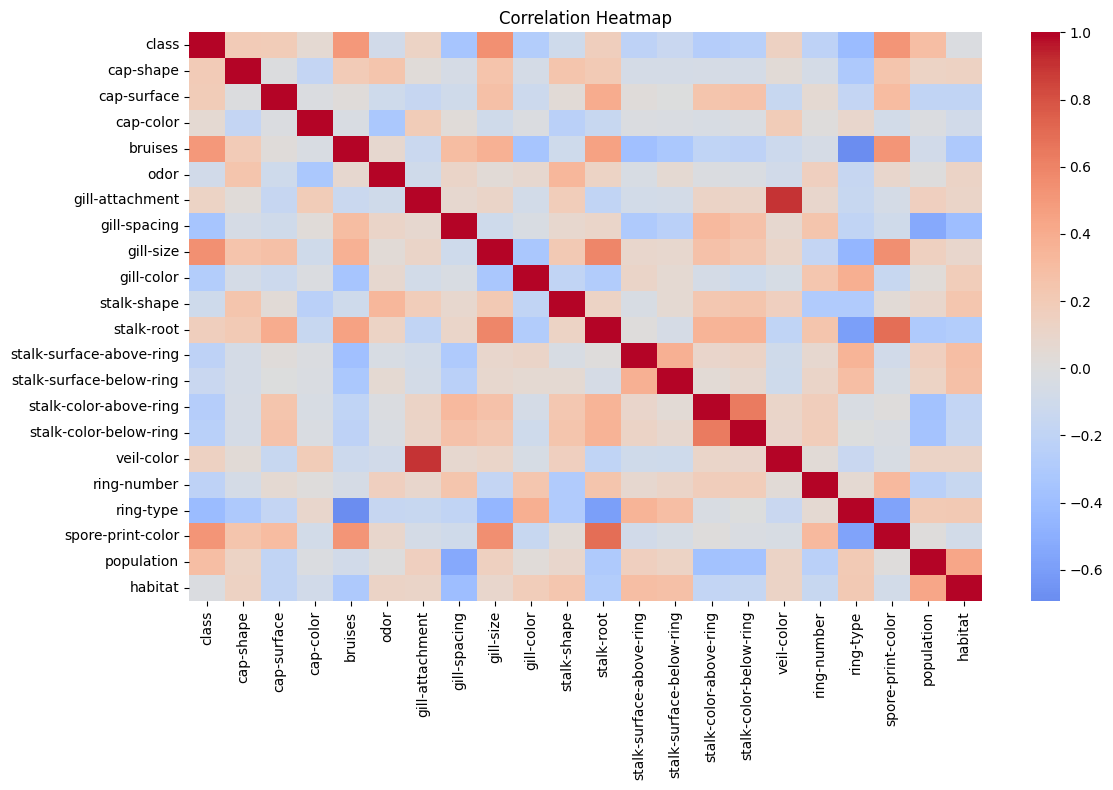

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif

df = df.drop(columns=["veil-type"], errors="ignore")

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="class")
plt.tight_layout()
plt.show()

features = ["odor", "gill-size", "habitat", "spore-print-color"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.countplot(data=df, x=col, hue="class", ax=axes[i])
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

df_enc = df.copy()
for col in df_enc.columns:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

X = df_enc.drop("class", axis=1)
y = df_enc["class"]

mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values()

plt.figure(figsize=(8, 6))
mi_series.plot(kind="barh")
plt.title("Mutual Information with Class")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
sns.heatmap(df_enc.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 3. Selekcja cech


In [3]:
from sklearn.model_selection import train_test_split, StratifiedKFold


columns_to_drop = [
    "stalk-shape",       
    "gill-attachment",   
    "veil-color",        
    "ring-number",       
    "cap-surface",       
    "cap-color",         
    "cap-shape",         
]

df_cleaned = df_enc.drop(columns=columns_to_drop, errors="ignore")

X = df_cleaned.drop("class", axis=1)
y = df_cleaned["class"]

print(f"Liczba cech po selekcji: {X.shape[1]}")
print(f"Cechy: {list(X.columns)}")


skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Liczba cech po selekcji: 14
Cechy: ['bruises', 'odor', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'ring-type', 'spore-print-color', 'population', 'habitat']


## 4. Modele

### 4.1 Drzewo decyzyjne


In [4]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix

param_grid_tree = {
    "max_depth": [3, 4, 5, 6, 8, 10],
    "criterion": ["gini", "entropy"],
    "min_samples_split": [2, 5, 10]
}


grid_tree = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_tree,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_


tree_preds = best_tree.predict(X_test)

print("--- DRZEWO PO GRID SEARCH Z CV ---")
print(f"Najlepsze parametry: {grid_tree.best_params_}")
print(f"Głębokość drzewa: {best_tree.get_depth()}, liczba liści: {best_tree.get_n_leaves()}")
print(f"Train accuracy: {best_tree.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {best_tree.score(X_test, y_test):.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, tree_preds))
print("\nRaport klasyfikacji:")
print(classification_report(y_test, tree_preds))

--- DRZEWO PO GRID SEARCH Z CV ---
Najlepsze parametry: {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 2}
Głębokość drzewa: 4, liczba liści: 9
Train accuracy: 0.9763
Test accuracy:  0.9766

Macierz pomyłek:
[[804  38]
 [  0 783]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       842
           1       0.95      1.00      0.98       783

    accuracy                           0.98      1625
   macro avg       0.98      0.98      0.98      1625
weighted avg       0.98      0.98      0.98      1625



### 4.2 Random Forest

In [5]:
from sklearn.ensemble import RandomForestClassifier

param_grid_rf = {
    "n_estimators": [50, 100, 150],
    "max_depth": [4, 6, 8],
    "min_samples_leaf": [1, 2, 4]
}


grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

rf_preds = best_rf.predict(X_test)

print("--- RANDOM FOREST PO GRID SEARCH Z CV ---")
print(f"Najlepsze parametry: {grid_rf.best_params_}")
print(f"Train accuracy: {best_rf.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {best_rf.score(X_test, y_test):.4f}")
print("\nMacierz pomyłek:")
print(confusion_matrix(y_test, rf_preds))
print("\nRaport klasyfikacji:")
print(classification_report(y_test, rf_preds))

--- RANDOM FOREST PO GRID SEARCH Z CV ---
Najlepsze parametry: {'max_depth': 6, 'min_samples_leaf': 1, 'n_estimators': 50}
Train accuracy: 1.0000
Test accuracy:  1.0000

Macierz pomyłek:
[[842   0]
 [  0 783]]

Raport klasyfikacji:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



### 4.3 Bagging + Naive Bayes (model kontrolny)


In [6]:
from sklearn.ensemble import BaggingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import StratifiedKFold
import numpy as np

bagging_nb = BaggingClassifier(
    estimator=GaussianNB(),
    n_estimators=100,
    random_state=42
)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
fold_thresholds = []

for train_idx, val_idx in cv.split(X_train, y_train):
    X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    bagging_nb.fit(X_cv_train, y_cv_train)
    probs_val = bagging_nb.predict_proba(X_cv_val)[:, 1]

    poisonous_probs = probs_val[y_cv_val == 1]
    if len(poisonous_probs) > 0:
        fold_thresholds.append(float(np.min(poisonous_probs)))

threshold = float(np.min(fold_thresholds))
print(f"Progi z foldów: {[round(t, 4) for t in fold_thresholds]}")
print(f"Finalny próg (mediana z CV): {threshold:.4f}")

bagging_nb.fit(X_train, y_train)
probs_nb = bagging_nb.predict_proba(X_test)[:, 1]
nb_preds = (probs_nb >= threshold).astype(int)

print("--- BAGGING + NAIVE BAYES (model kontrolny, próg z CV) ---")
print(f"Train accuracy: {bagging_nb.score(X_train, y_train):.4f}")
print(f"Test accuracy:  {(nb_preds == y_test).mean():.4f}")
print("Macierz pomyłek:")
print(confusion_matrix(y_test, nb_preds))
print("Raport klasyfikacji:")
print(classification_report(y_test, nb_preds, target_names=["edible", "poisonous"]))


Progi z foldów: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
Finalny próg (mediana z CV): 0.0000
--- BAGGING + NAIVE BAYES (model kontrolny, próg z CV) ---
Train accuracy: 0.8977
Test accuracy:  0.5317
Macierz pomyłek:
[[ 81 761]
 [  0 783]]
Raport klasyfikacji:
              precision    recall  f1-score   support

      edible       1.00      0.10      0.18       842
   poisonous       0.51      1.00      0.67       783

    accuracy                           0.53      1625
   macro avg       0.75      0.55      0.42      1625
weighted avg       0.76      0.53      0.42      1625



## 5. Walidacja i porównanie modeli

In [7]:
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import brier_score_loss, recall_score, accuracy_score

# Drzewo i Random Forest: standardowy cross_val_score
for name, model, preds in [
    ("Drzewo decyzyjne", best_tree, tree_preds),
    ("Random Forest",    best_rf,   rf_preds),
]:
    acc_scores = cross_val_score(model, X, y, cv=skf, scoring="accuracy")
    rec_scores = cross_val_score(model, X, y, cv=skf, scoring="recall")
    probs = model.predict_proba(X_test)[:, 1]
    brier = brier_score_loss(y_test, probs)
    print(f"{name}")
    print(f"  CV accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
    print(f"  CV recall   : {rec_scores.mean():.4f} ± {rec_scores.std():.4f}")
    print(f"  Brier score : {brier:.4f}")
    print()


cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
nb_cv_acc, nb_cv_rec = [], []

for train_idx, val_idx in cv.split(X, y):
    X_cv_train, X_cv_val = X.iloc[train_idx], X.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]

    bagging_nb.fit(X_cv_train, y_cv_train)
    probs_val = bagging_nb.predict_proba(X_cv_val)[:, 1]

    # próg = min P(poisonous) wśród prawdziwie trujących w tym foldzie
    poisonous_probs = probs_val[y_cv_val == 1]
    fold_threshold = float(np.min(poisonous_probs)) if len(poisonous_probs) > 0 else 0.5

    fold_preds = (probs_val >= fold_threshold).astype(int)
    nb_cv_acc.append(accuracy_score(y_cv_val, fold_preds))
    nb_cv_rec.append(recall_score(y_cv_val, fold_preds))

probs_nb_test = bagging_nb.predict_proba(X_test)[:, 1]
brier_nb = brier_score_loss(y_test, probs_nb_test)

print("Bagging + Naive Bayes (próg dobierany w każdym foldzie CV)")
print(f"  CV accuracy : {np.mean(nb_cv_acc):.4f} ± {np.std(nb_cv_acc):.4f}")
print(f"  CV recall   : {np.mean(nb_cv_rec):.4f} ± {np.std(nb_cv_rec):.4f}")
print(f"  Brier score : {brier_nb:.4f}")
print()


print("Czas predykcji – drzewo decyzyjne:")
tree_time = %timeit -o -q best_tree.predict(X_test)
print(tree_time)

print("Czas predykcji – Random Forest:")
rf_time = %timeit -o -q best_rf.predict(X_test)
print(rf_time)

print("Czas predykcji – Bagging + Naive Bayes:")
nb_time = %timeit -o -q bagging_nb.predict(X_test)
print(nb_time)

print(f"Random Forest jest {rf_time.average / tree_time.average:.1f}× wolniejszy od drzewa decyzyjnego.")
print(f"Bagging+NB jest {nb_time.average / tree_time.average:.1f}× wolniejszy od drzewa decyzyjnego.")


Drzewo decyzyjne
  CV accuracy : 0.9764 ± 0.0048
  CV recall   : 1.0000 ± 0.0000
  Brier score : 0.0168

Random Forest
  CV accuracy : 1.0000 ± 0.0000
  CV recall   : 1.0000 ± 0.0000
  Brier score : 0.0026

Bagging + Naive Bayes (próg dobierany w każdym foldzie CV)
  CV accuracy : 0.5545 ± 0.0363
  CV recall   : 1.0000 ± 0.0000
  Brier score : 0.0914

Czas predykcji – drzewo decyzyjne:
328 μs ± 17.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
Czas predykcji – Random Forest:
3.65 ms ± 199 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Czas predykcji – Bagging + Naive Bayes:
23.3 ms ± 917 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)
Random Forest jest 11.1× wolniejszy od drzewa decyzyjnego.
Bagging+NB jest 71.1× wolniejszy od drzewa decyzyjnego.


### 5.1 Porównanie macierzy pomyłek


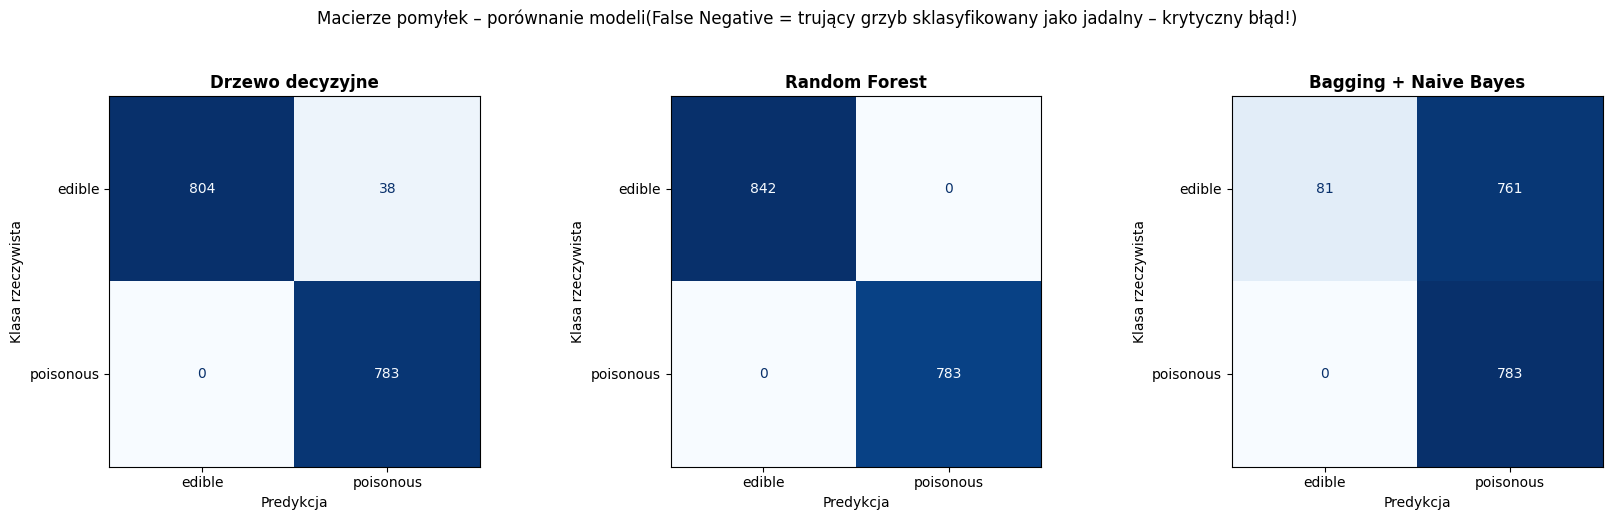

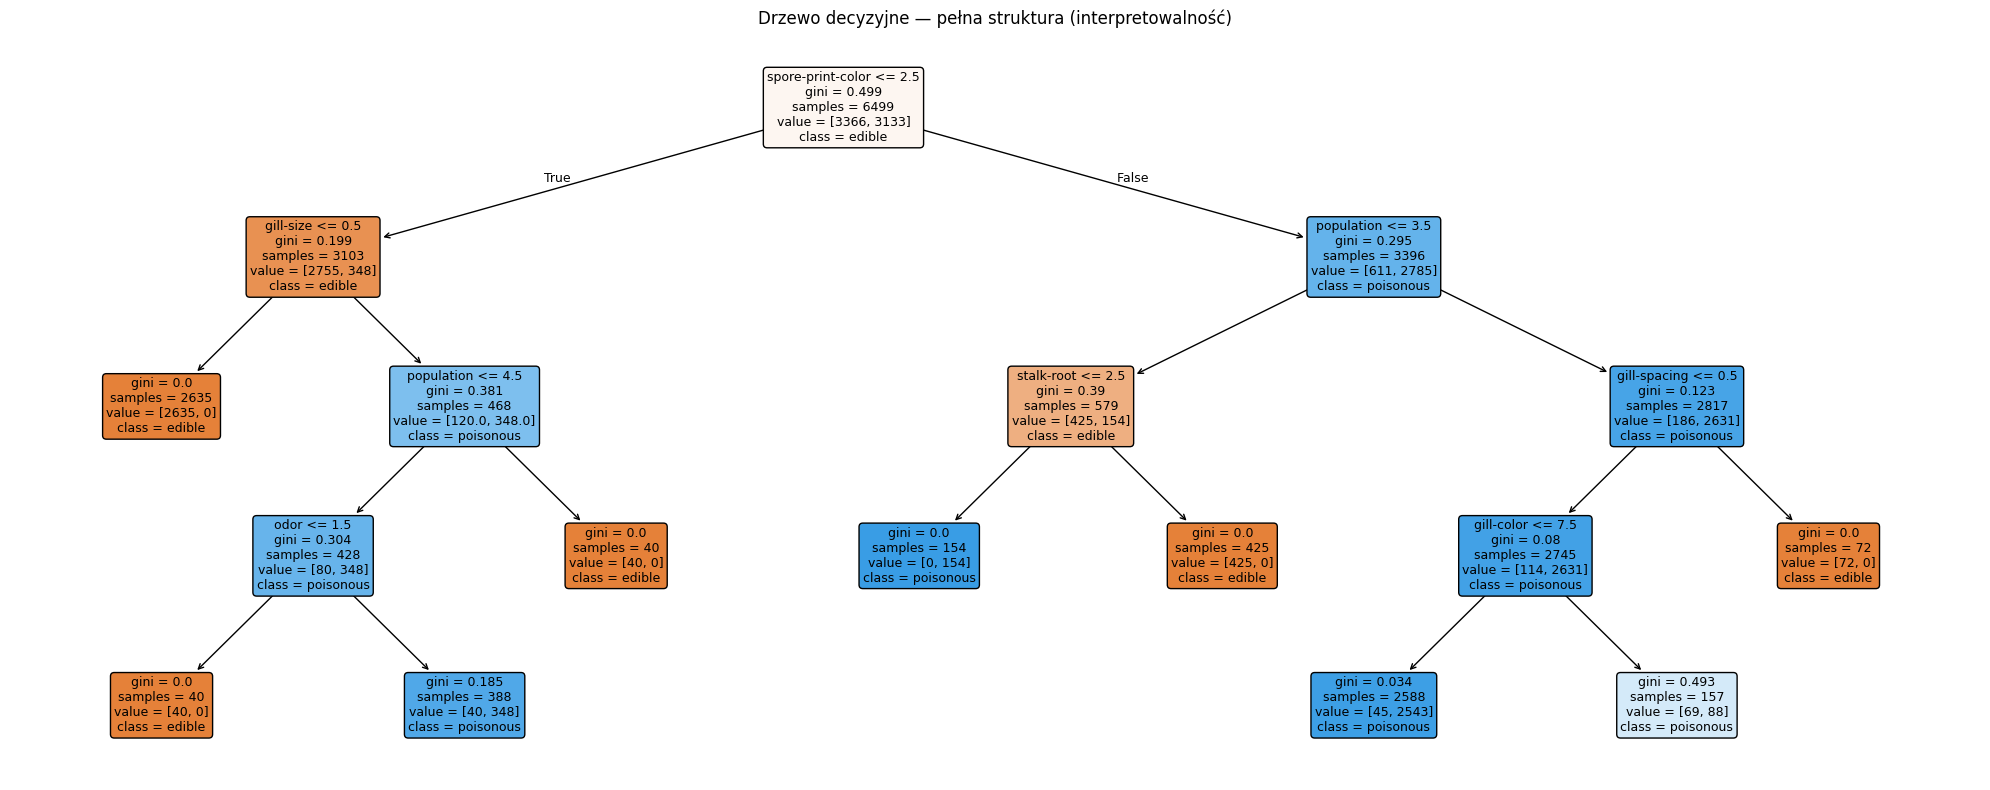

In [8]:
from sklearn.metrics import ConfusionMatrixDisplay

models_cm = [
    ("Drzewo decyzyjne",      best_tree,  tree_preds),
    ("Random Forest",         best_rf,    rf_preds),
    ("Bagging + Naive Bayes", bagging_nb, nb_preds),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, model, preds) in zip(axes, models_cm):
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, preds,
        display_labels=["edible", "poisonous"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predykcja", fontsize=10)
    ax.set_ylabel("Klasa rzeczywista", fontsize=10)

plt.suptitle(
    "Macierze pomyłek – porównanie modeli"
    "(False Negative = trujący grzyb sklasyfikowany jako jadalny – krytyczny błąd!)",
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()


from sklearn.tree import plot_tree

plt.figure(figsize=(20, 8))
plot_tree(
    best_tree,
    feature_names=X.columns.tolist(),
    class_names=["edible", "poisonous"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Drzewo decyzyjne — pełna struktura (interpretowalność)")
plt.tight_layout()
plt.show()


## 6. Wnioski

In [ ]:
# WNIOSKI:
#
# Dane o grzybach są deterministyczne – każda kombinacja cech jednoznacznie
# mapuje się na jadalny/trujący, bez szumu ani przypadków granicznych.
# Dlatego drzewo i Random Forest osiągają praktycznie 100% na każdej metryce.
#
# Bagging + Naive Bayes jako model kontrolny pokazuje, że to nie jest
# zasługa samego mechanizmu ensemble. NB zakłada niezależność cech,
# co heatmapa korelacji z EDA obala. Bagging uśrednia 100 modeli
# popełniających ten sam błąd – różnorodność jest pozorna.
# Bez dostrojenia progu pojawiają się False Negative (trujące grzyby
# jako jadalne). Po dostrojeniu progu przez CV recall wraca do 1.0,
# ale kosztem dużej liczby fałszywych alarmów i gorszej accuracy.
#
# Najsilniejszą cechą jest zapach (odor) – sam w sobie daje ~98% accuracy.
# Drzewo uczy się tej reguły wprost, NB traktuje ją jak jeden
# z wielu równorzędnych sygnałów i przez to ją rozmywa.
#
# REKOMENDACJA: drzewo decyzyjne.
# Random Forest daje identyczny wynik, ale jest wielokrotnie wolniejszy
# i działa jak czarna skrzynka. W lesie z rozładowaną baterią liczy się
# każda milisekunda i to że można zrozumieć decyzję modelu bez znajomości
# statystyki – a drzewo po prostu można przeczytać.